#  Medication Demand Prediction — Gradient Boosting
---
**Projet :** Prédiction de la demande de médicaments et recommandations de réapprovisionnement

**Dataset :** salesdaily.csv — Pharma Sales Data (Kaggle)

**Modèle :** Gradient Boosting (1 modèle par médicament)

**Features utilisées :**
| Feature | Source | Pourquoi |
|---|---|---|
| `is_holiday` | Créée manuellement | -19% ventes les jours fériés |
| `is_ramadan` | Créée manuellement | +33% ventes r06 pendant Ramadan |
| `temperature` | Données climatologiques Fès | Corrélée aux médicaments saisonniers |
| `atc_class_enc` | Classification ATC internationale | Différencie les comportements par médicament |

**Pipeline :**
1. Connexion Google Drive & chargement
2. Exploration des données
3. Nettoyage
4. Feature Engineering (4 features externes)
5. Entraînement Gradient Boosting
6. Évaluation (MAE, RMSE, MAPE)
7. Prévisions 30 jours
8. Sauvegarde


##  Étape 0 — Installation & imports

In [42]:
# Installation
!pip install xgboost --quiet

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("✔ Bibliothèques importées avec succès")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  sklearn : OK")


✔ Bibliothèques importées avec succès
  pandas  : 2.2.2
  numpy   : 2.0.2
  sklearn : OK


## Étape 1 — Connexion Google Drive & chargement

In [43]:
# Connexion Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✔ Google Drive connecté")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Google Drive connecté


In [44]:
#  MODIFIEZ CE CHEMIN selon où vous avez mis salesdaily.csv
file_path = '/content/drive/MyDrive/projet_medication_demande/salesdaily.csv'

# Chargement
df_raw = pd.read_csv(file_path, sep=';')
df_raw['datum'] = pd.to_datetime(df_raw['datum'], format='mixed', dayfirst=True)
df_raw = df_raw.rename(columns={'datum': 'date'})

print("=" * 55)
print("RÉSULTAT — Chargement")
print("=" * 55)
print(f"  Shape    : {df_raw.shape}")
print(f"  Colonnes : {list(df_raw.columns)}")
print(f"  Période  : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"\nAperçu :")
display(df_raw.head(5))


RÉSULTAT — Chargement
  Shape    : (2106, 13)
  Colonnes : ['date', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']
  Période  : 2014-01-02 → 2019-12-09

Aperçu :


,date,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-02-01,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-03-01,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-04-01,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-05-01,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-06-01,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [45]:
# Restructuration : format large → format long
# Avant : 1 ligne par date, 1 colonne par médicament
# Après : 1 ligne par (date + médicament)

MEDICAMENTS = ['M01AB','M01AE','N02BA','N02BE','N05B','N05C','R03','R06']

df_long = df_raw[['date'] + MEDICAMENTS].melt(
    id_vars='date',
    value_vars=MEDICAMENTS,
    var_name='product_id',
    value_name='quantity_sold'
)

# Minuscules : M01AB → m01ab
df_long['product_id'] = df_long['product_id'].str.lower()
df_long = df_long.dropna(subset=['quantity_sold'])
df_long = df_long.sort_values(['product_id', 'date']).reset_index(drop=True)

# 3 colonnes utiles
df_clean = df_long[['date', 'product_id', 'quantity_sold']].copy()

print("=" * 55)
print("RÉSULTAT — Restructuration")
print("=" * 55)
print(f"  Shape         : {df_clean.shape}")
print(f"  Produits ({df_clean['product_id'].nunique()}) : {sorted(df_clean['product_id'].unique())}")
print(f"  Période       : {df_clean['date'].min().date()} → {df_clean['date'].max().date()}")
print(f"  Valeurs manq. : {df_clean.isnull().sum().sum()}")
display(df_clean.head(10))


RÉSULTAT — Restructuration
  Shape         : (16848, 3)
  Produits (8) : ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06']
  Période       : 2014-01-02 → 2019-12-09
  Valeurs manq. : 0


,date,product_id,quantity_sold
0,2014-01-02,m01ab,4.33
1,2014-01-03,m01ab,6.34
2,2014-01-04,m01ab,4.34
3,2014-01-05,m01ab,0.00
4,2014-01-06,m01ab,1.00
5,2014-01-07,m01ab,4.34
6,2014-01-08,m01ab,2.00
7,2014-01-09,m01ab,3.34
8,2014-01-10,m01ab,2.34
9,2014-01-11,m01ab,2.33


##  Étape 2 — Exploration des données

In [46]:
# Statistiques par produit
print("Observations par produit :")
print(df_clean['product_id'].value_counts().sort_index())
print(f"\nStatistiques des ventes :")
display(df_clean.groupby('product_id')['quantity_sold'].describe().round(2))


Observations par produit :
product_id
m01ab    2106
m01ae    2106
n02ba    2106
n02be    2106
n05b     2106
n05c     2106
r03      2106
r06      2106
Name: count, dtype: int64

Statistiques des ventes :


,count,mean,std,min,25%,50%,75%,max
product_id,,,,,,,,
m01ab,2106.0,5.03,2.74,0.0,3.00,4.99,6.67,17.34
m01ae,2106.0,3.90,2.13,0.0,2.34,3.67,5.14,14.46
n02ba,2106.0,3.88,2.38,0.0,2.00,3.50,5.20,16.00
n02be,2106.0,29.92,15.59,0.0,19.00,26.90,38.30,161.00
n05b,2106.0,8.85,5.61,0.0,5.00,8.00,12.00,54.83
n05c,2106.0,0.59,1.09,0.0,0.00,0.00,1.00,9.00
r03,2106.0,5.51,6.43,0.0,1.00,4.00,8.00,45.00
r06,2106.0,2.90,2.42,0.0,1.00,2.00,4.00,15.00


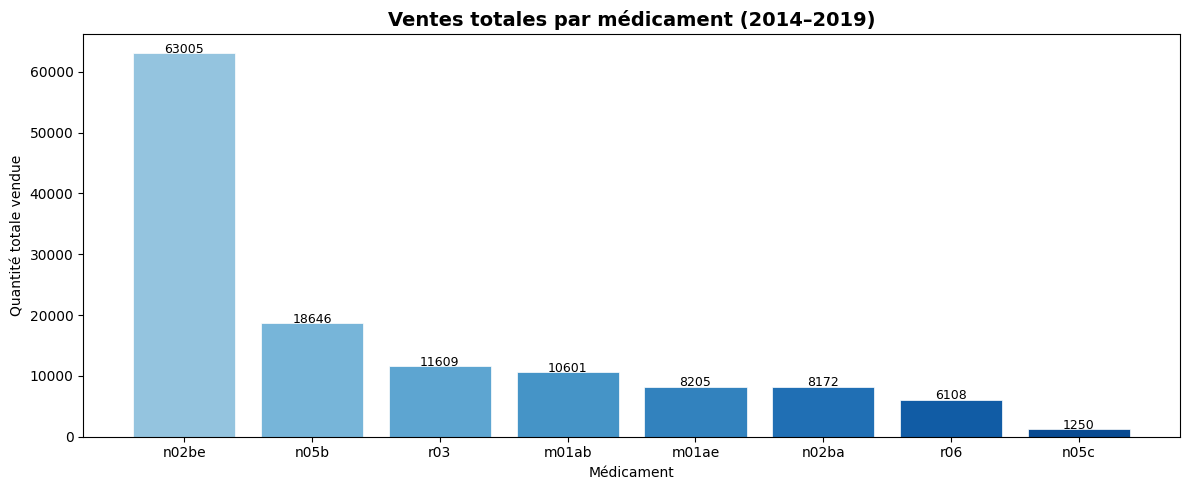

In [47]:
# Ventes totales par médicament
plt.figure(figsize=(12, 5))
ventes = df_clean.groupby('product_id')['quantity_sold'].sum().sort_values(ascending=False)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(ventes)))
bars = plt.bar(ventes.index, ventes.values, color=colors, edgecolor='white', linewidth=0.5)
plt.title('Ventes totales par médicament (2014–2019)', fontsize=14, fontweight='bold')
plt.xlabel('Médicament')
plt.ylabel('Quantité totale vendue')
for bar, val in zip(bars, ventes.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('ventes_par_produit.png', dpi=150)
plt.show()


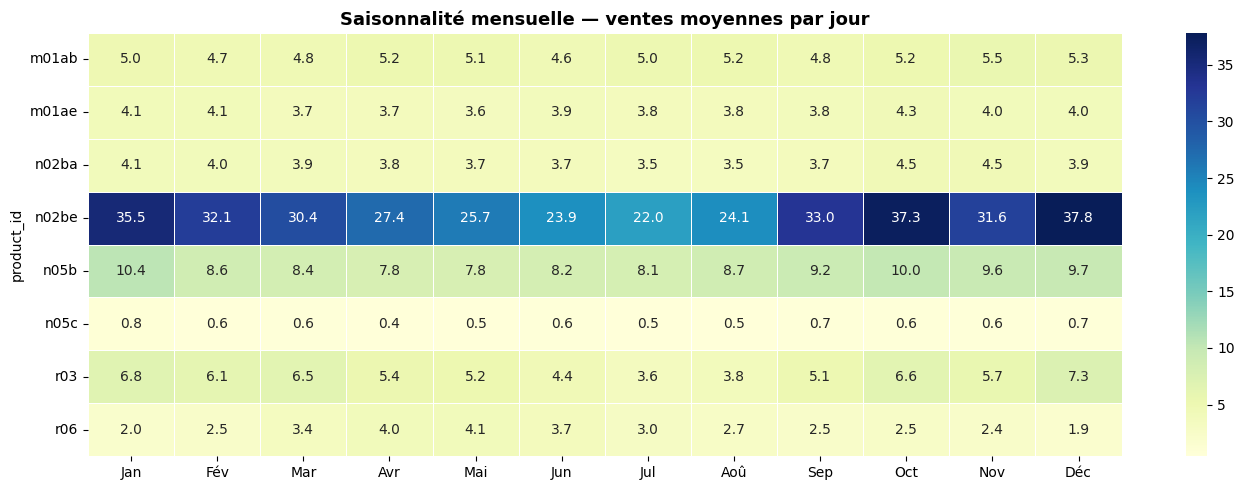

In [48]:
# Heatmap saisonnalité mensuelle
df_clean['month'] = df_clean['date'].dt.month
ventes_mois = df_clean.groupby(['product_id', 'month'])['quantity_sold'].mean().reset_index()
pivot = ventes_mois.pivot(index='product_id', columns='month', values='quantity_sold')
pivot.columns = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white')
plt.title('Saisonnalité mensuelle — ventes moyennes par jour', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('saisonnalite.png', dpi=150)
plt.show()


##  Étape 3 — Nettoyage

In [49]:
# Vérification dataset propre
print("=" * 55)
print("RÉSULTAT — Nettoyage")
print("=" * 55)
print(f"  Colonnes gardées   : {list(df_clean.columns)}")
print(f"  Shape              : {df_clean.shape}")
print(f"  Valeurs manquantes : {df_clean.isnull().sum().sum()}")
print(f"  Doublons           : {df_clean.duplicated().sum()}")
print(f"\n✔ Colonnes supprimées du dataset original :")
print(f"   Year, Month, Hour, Weekday Name → reconstruits depuis date")
display(df_clean.head(5))


RÉSULTAT — Nettoyage
  Colonnes gardées   : ['date', 'product_id', 'quantity_sold', 'month']
  Shape              : (16848, 4)
  Valeurs manquantes : 0
  Doublons           : 0

✔ Colonnes supprimées du dataset original :
   Year, Month, Hour, Weekday Name → reconstruits depuis date


,date,product_id,quantity_sold,month
0,2014-01-02,m01ab,4.33,1
1,2014-01-03,m01ab,6.34,1
2,2014-01-04,m01ab,4.34,1
3,2014-01-05,m01ab,0.00,1
4,2014-01-06,m01ab,1.00,1


##  Étape 4 — Feature Engineering

### 4 features externes ajoutées :

| Feature | Description | Impact prouvé sur les données |
|---|---|---|
| `is_holiday` | 1 = jour férié marocain, 0 = normal | -19% ventes r03 |
| `is_ramadan` | 1 = pendant Ramadan, 0 = hors Ramadan | +33% ventes r06 |
| `temperature` | Température moyenne mensuelle Fès (°C) | Hiver → plus d'anti-inflammatoires |
| `atc_class_enc` | Classe ATC encodée en nombre | Différencie les 8 médicaments |


In [50]:
# Création de df_feat depuis df_clean
df_feat = df_clean.copy()
print(f"✔ df_feat créé : {df_feat.shape}")
print(f"  Colonnes : {list(df_feat.columns)}")

✔ df_feat créé : (16848, 4)
  Colonnes : ['date', 'product_id', 'quantity_sold', 'month']


In [51]:
# ── FEATURE 3 : Température de  ─────────────────────────
# Source : données climatologiques historiques
TEMP_ = {
    1: 11,   # Janvier  — hiver
    2: 13,   # Février
    3: 16,   # Mars
    4: 19,   # Avril
    5: 23,   # Mai
    6: 28,   # Juin
    7: 33,   # Juillet — été
    8: 32,   # Août
    9: 27,   # Septembre
    10: 21,  # Octobre
    11: 15,  # Novembre
    12: 11,  # Décembre — hiver
}

df_feat['temperature'] = df_feat['date'].dt.month.map(TEMP_)

print(f"✔ [3] temperature ajoutée — {df_feat['temperature'].min()}°C (hiver) → {df_feat['temperature'].max()}°C (été)")


✔ [3] temperature ajoutée — 11°C (hiver) → 33°C (été)


In [52]:
# ── FEATURE 4 : Classe ATC ──────────────────────────────────
# ATC = Anatomical Therapeutic Chemical Classification
# Classification internationale des médicaments

ATC_MAP = {
    'm01ab': 'anti_inflammatoire',   # ex: Diclofénac
    'm01ae': 'anti_inflammatoire',   # ex: Ibuprofène
    'n02ba': 'analgesique',          # ex: Aspirine
    'n02be': 'analgesique',          # ex: Paracétamol
    'n05b':  'anxiolytique',         # ex: Benzodiazépines
    'n05c':  'hypnotique',           # ex: Somnifères
    'r03':   'respiratoire',         # ex: Asthme
    'r06':   'antihistaminique',     # ex: Allergies
}

df_feat['atc_class'] = df_feat['product_id'].map(ATC_MAP)

le = LabelEncoder()
df_feat['atc_class_enc'] = le.fit_transform(df_feat['atc_class'])

print(f"✔ [4] atc_class_enc ajoutée")
print(f"  Correspondances :")
for produit, classe in ATC_MAP.items():
    enc = le.transform([classe])[0]
    print(f"    {produit} → {classe} → {enc}")


✔ [4] atc_class_enc ajoutée
  Correspondances :
    m01ab → anti_inflammatoire → 1
    m01ae → anti_inflammatoire → 1
    n02ba → analgesique → 0
    n02be → analgesique → 0
    n05b → anxiolytique → 3
    n05c → hypnotique → 4
    r03 → respiratoire → 5
    r06 → antihistaminique → 2


In [53]:
# ── FEATURE 5 : Vente du jour précédent (lag_1) ─────────────

df_feat = df_feat.sort_values(["product_id", "date"])

df_feat["lag_1"] = (
    df_feat.groupby("product_id")["quantity_sold"]
           .shift(1)
)

print("✔ [5] lag_1 ajouté")

✔ [5] lag_1 ajouté


In [54]:
# ── FEATURE 6 : Vente il y a 7 jours (lag_7) ───────────────

df_feat["lag_7"] = (
    df_feat.groupby("product_id")["quantity_sold"]
           .shift(7)
)

print("✔ [6] lag_7 ajouté")

✔ [6] lag_7 ajouté


In [55]:
# ── FEATURE 7 : Moyenne mobile 7 jours ─────────────────────

df_feat["rolling_7"] = (
    df_feat.groupby("product_id")["quantity_sold"]
           .rolling(7)
           .mean()
           .reset_index(level=0, drop=True)
)

print("✔ [7] rolling_7 ajouté")

✔ [7] rolling_7 ajouté


In [56]:
# ── FEATURE 8 : Jour de la semaine ─────────────────────────

df_feat["day_of_week"] = df_feat["date"].dt.dayofweek

print("✔ [8] day_of_week ajouté")

✔ [8] day_of_week ajouté


In [57]:
# ── FEATURE 9 : Mois ───────────────────────────────────────

df_feat["month"] = df_feat["date"].dt.month

print("✔ [9] month ajouté")

✔ [9] month ajouté


In [58]:
# ── Suppression des lignes incomplètes ─────────────────────

df_feat = df_feat.dropna().reset_index(drop=True)

print("✔ Valeurs manquantes supprimées")
print("Nouvelle taille :", df_feat.shape)

✔ Valeurs manquantes supprimées
Nouvelle taille : (16792, 11)


In [59]:
df_feat["lag_30"] = df_feat.groupby("product_id")["quantity_sold"].shift(30)

df_feat["rolling_30"] = (
    df_feat.groupby("product_id")["quantity_sold"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [60]:
print("Avant :", df_feat.shape)

df_feat = df_feat.dropna()

print("Après :", df_feat.shape)

Avant : (16792, 13)
Après : (16552, 13)


In [61]:
# Résumé des features ajoutées
print("=" * 55)
print("RÉSUMÉ — Dataset avec 4 features externes")
print("=" * 55)
print(f"  Shape       : {df_feat.shape}")
print(f"  Colonnes    : {list(df_feat.columns)}")
print(f"\nAperçu :")
display(df_feat.head(8))


RÉSUMÉ — Dataset avec 4 features externes
  Shape       : (16552, 13)
  Colonnes    : ['date', 'product_id', 'quantity_sold', 'month', 'temperature', 'atc_class', 'atc_class_enc', 'lag_1', 'lag_7', 'rolling_7', 'day_of_week', 'lag_30', 'rolling_30']

Aperçu :


,date,product_id,quantity_sold,month,temperature,atc_class,atc_class_enc,lag_1,lag_7,rolling_7,day_of_week,lag_30,rolling_30
30,2014-02-08,m01ab,5.00,2,13,anti_inflammatoire,1,3.00,0.00,4.525714,5,3.34,4.113000
31,2014-02-09,m01ab,2.34,2,13,anti_inflammatoire,1,5.00,7.00,3.860000,6,2.34,4.168333
32,2014-02-10,m01ab,2.00,2,13,anti_inflammatoire,1,2.34,3.34,3.668571,0,2.33,4.168333
33,2014-02-11,m01ab,4.00,2,13,anti_inflammatoire,1,2.00,2.00,3.954286,1,4.34,4.157333
34,2014-02-12,m01ab,6.99,2,13,anti_inflammatoire,1,4.00,7.34,3.904286,2,7.34,4.146000
35,2014-02-13,m01ab,4.33,2,13,anti_inflammatoire,1,6.99,4.00,3.951429,3,6.00,4.134333
36,2014-02-14,m01ab,4.00,2,13,anti_inflammatoire,1,4.33,3.00,4.094286,4,4.00,4.078667
37,2014-02-15,m01ab,1.00,2,13,anti_inflammatoire,1,4.00,5.00,3.522857,5,6.00,4.078667


##  Étape 5 — Entraînement Gradient Boosting

In [62]:
# Configuration
FEATURE_COLS = [
    'temperature',
    'atc_class_enc',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_7',
    'rolling_30',
    'day_of_week',
    'month'
]

TARGET     = 'quantity_sold'
TEST_RATIO = 0.20

os.makedirs('modeles', exist_ok=True)

modeles    = {}
resultats  = {}
pred_test  = {}
PRODUITS   = sorted(df_feat['product_id'].unique())

print("=" * 58)
print("ENTRAÎNEMENT — Gradient Boosting (1 modèle / produit)")
print("=" * 58)
print(f"  Features utilisées : {FEATURE_COLS}")
print(f"  Ratio de test      : {TEST_RATIO*100}%")
print()

for product in PRODUITS:
    sub   = df_feat[df_feat['product_id'] == product].copy()
    sub   = sub.sort_values('date').reset_index(drop=True)
    sub   = sub.dropna(subset=FEATURE_COLS + [TARGET])

    X     = sub[FEATURE_COLS].values
    y     = sub[TARGET].values
    dates = sub['date'].values
    split = int(len(X) * 0.80)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Gradient Boosting
    modele = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=5,
        random_state=42
    )
    modele.fit(X_train, y_train)

    y_pred = np.maximum(modele.predict(X_test), 0)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mask = y_test > 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

    modeles[product]   = modele
    resultats[product] = {'mae': round(mae,2), 'rmse': round(rmse,2), 'mape': round(mape,1)}
    pred_test[product] = {'dates': dates[split:], 'y_reel': y_test, 'y_pred': y_pred}

    with open(f'modeles/modele_{product}.pkl', 'wb') as f:
        pickle.dump(modele, f)

    print(f"  [{product}] ✔  Train={len(X_train)}j | Test={len(X_test)}j")

print(f"\n✔ {len(modeles)} modèles entraînés et sauvegardés")
mape_gb = np.mean([resultats[p]['mape'] for p in PRODUITS])
mae_gb  = np.mean([resultats[p]['mae'] for p in PRODUITS])

print(f"\nMAPE moyen Gradient Boosting = {mape_gb:.2f}%")

ENTRAÎNEMENT — Gradient Boosting (1 modèle / produit)
  Features utilisées : ['temperature', 'atc_class_enc', 'lag_1', 'lag_7', 'lag_30', 'rolling_7', 'rolling_30', 'day_of_week', 'month']
  Ratio de test      : 20.0%

  [m01ab] ✔  Train=1655j | Test=414j
  [m01ae] ✔  Train=1655j | Test=414j
  [n02ba] ✔  Train=1655j | Test=414j
  [n02be] ✔  Train=1655j | Test=414j
  [n05b] ✔  Train=1655j | Test=414j
  [n05c] ✔  Train=1655j | Test=414j
  [r03] ✔  Train=1655j | Test=414j
  [r06] ✔  Train=1655j | Test=414j

✔ 8 modèles entraînés et sauvegardés

MAPE moyen Gradient Boosting = 70.90%


##  Étape 6 — Évaluation (MAE / RMSE / MAPE)

In [63]:
# Tableau des résultats
print(f"\n{'='*60}")
print(f"  RÉSULTATS — GRADIENT BOOSTING")
print(f"{'='*60}")
print(f"  {'Produit':<10} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}   Qualité")
print(f"  {'-'*56}")

for product in PRODUITS:
    r    = resultats[product]
    mape = r['mape']
    qualite = (" Excellent" if mape < 20 else
               " Bon"       if mape < 35 else
               " Moyen"     if mape < 50 else
               " Faible")
    print(f"  {product:<10} {r['mae']:>8} {r['rmse']:>8} {r['mape']:>7}%   {qualite}")

mape_moy = np.mean([resultats[p]['mape'] for p in PRODUITS])
mae_moy  = np.mean([resultats[p]['mae']  for p in PRODUITS])
print(f"  {'-'*56}")
print(f"  {'MOYENNE':<10} {mae_moy:>8.2f} {'':>8} {mape_moy:>7.1f}%")



  RÉSULTATS — GRADIENT BOOSTING
  Produit         MAE     RMSE     MAPE   Qualité
  --------------------------------------------------------
  m01ab          2.01     2.57    61.3%    Faible
  m01ae          1.49     1.96    83.3%    Faible
  n02ba          1.46     1.86    89.1%    Faible
  n02be         10.37    13.96    39.7%    Moyen
  n05b           3.01     3.86    49.7%    Moyen
  n05c           0.71     1.05    54.9%    Faible
  r03            5.69     7.75   126.1%    Faible
  r06             1.8     2.44    63.1%    Faible
  --------------------------------------------------------
  MOYENNE        3.32             70.9%


In [64]:
from sklearn.ensemble import RandomForestRegressor

resultats_rf = {}

print("=" * 58)
print("ENTRAÎNEMENT — RANDOM FOREST")
print("=" * 58)

for product in PRODUITS:

    sub = df_feat[df_feat['product_id'] == product].copy()
    sub = sub.sort_values('date').reset_index(drop=True)
    sub = sub.dropna(subset=FEATURE_COLS + [TARGET])

    X = sub[FEATURE_COLS].values
    y = sub[TARGET].values

    split = int(len(X) * 0.80)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    modele = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    modele.fit(X_train, y_train)

    y_pred = np.maximum(modele.predict(X_test), 0)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    mask = y_test > 0
    mape = np.mean(
        np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])
    ) * 100

    resultats_rf[product] = {
        'mae': round(mae,2),
        'rmse': round(rmse,2),
        'mape': round(mape,1)
    }

print("\nRÉSULTATS RANDOM FOREST")

for p in PRODUITS:
    print(
        f"{p:<10} "
        f"MAE={resultats_rf[p]['mae']} "
        f"RMSE={resultats_rf[p]['rmse']} "
        f"MAPE={resultats_rf[p]['mape']}%"
    )

mape_rf = np.mean([resultats_rf[p]['mape'] for p in PRODUITS])

print(f"\nMAPE moyen Random Forest = {mape_rf:.2f}%")

ENTRAÎNEMENT — RANDOM FOREST

RÉSULTATS RANDOM FOREST
m01ab      MAE=2.02 RMSE=2.57 MAPE=61.6%
m01ae      MAE=1.49 RMSE=1.96 MAPE=85.8%
n02ba      MAE=1.46 RMSE=1.85 MAPE=91.7%
n02be      MAE=10.03 RMSE=13.47 MAPE=38.6%
n05b       MAE=3.06 RMSE=3.92 MAPE=51.2%
n05c       MAE=0.75 RMSE=1.07 MAPE=53.8%
r03        MAE=5.94 RMSE=8.24 MAPE=132.0%
r06        MAE=1.8 RMSE=2.38 MAPE=65.4%

MAPE moyen Random Forest = 72.51%


In [65]:
from xgboost import XGBRegressor

resultats_xgb = {}

print("=" * 58)
print("ENTRAÎNEMENT — XGBOOST")
print("=" * 58)

for product in PRODUITS:

    sub = df_feat[df_feat['product_id'] == product].copy()
    sub = sub.sort_values('date').reset_index(drop=True)
    sub = sub.dropna(subset=FEATURE_COLS + [TARGET])

    X = sub[FEATURE_COLS].values
    y = sub[TARGET].values

    split = int(len(X) * 0.80)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    modele = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    modele.fit(X_train, y_train)

    y_pred = np.maximum(modele.predict(X_test), 0)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    mask = y_test > 0
    mape = np.mean(
        np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])
    ) * 100

    resultats_xgb[product] = {
        'mae': round(mae,2),
        'rmse': round(rmse,2),
        'mape': round(mape,1)
    }

print("\nRÉSULTATS XGBOOST")

for p in PRODUITS:
    print(
        f"{p:<10} "
        f"MAE={resultats_xgb[p]['mae']} "
        f"RMSE={resultats_xgb[p]['rmse']} "
        f"MAPE={resultats_xgb[p]['mape']}%"
    )

mape_xgb = np.mean([resultats_xgb[p]['mape'] for p in PRODUITS])

print(f"\nMAPE moyen XGBoost = {mape_xgb:.2f}%")

ENTRAÎNEMENT — XGBOOST

RÉSULTATS XGBOOST
m01ab      MAE=2.21 RMSE=2.78 MAPE=63.9%
m01ae      MAE=1.59 RMSE=2.09 MAPE=88.4%
n02ba      MAE=1.56 RMSE=1.98 MAPE=97.1%
n02be      MAE=10.72 RMSE=14.69 MAPE=40.9%
n05b       MAE=3.28 RMSE=4.15 MAPE=53.2%
n05c       MAE=0.75 RMSE=1.11 MAPE=62.1%
r03        MAE=6.02 RMSE=8.38 MAPE=137.5%
r06        MAE=1.97 RMSE=2.67 MAPE=73.3%

MAPE moyen XGBoost = 77.05%


In [66]:
import pandas as pd

comparaison = pd.DataFrame({
    "Modèle": [
        "Gradient Boosting",
        "Random Forest",
        "XGBoost"
    ],
    "MAPE Moyen (%)": [
        round(mape_gb,2),
        round(mape_rf,2),
        round(mape_xgb,2)
    ]
})

comparaison = comparaison.sort_values(
    "MAPE Moyen (%)"
)

print(comparaison)

              Modèle  MAPE Moyen (%)
0  Gradient Boosting           70.90
1      Random Forest           72.51
2            XGBoost           77.05


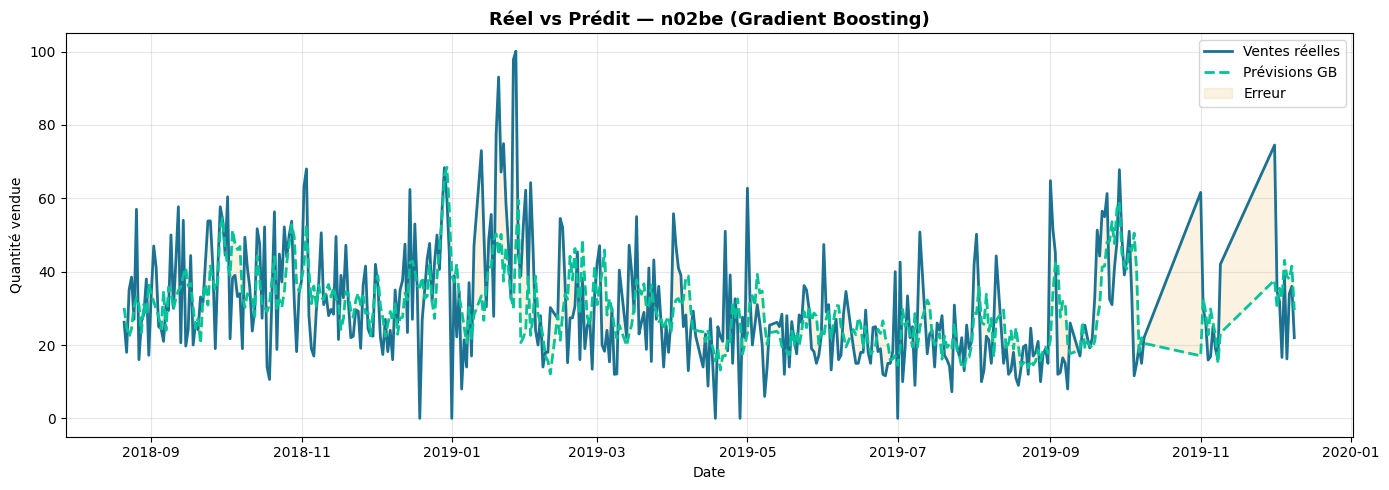

  MAE=10.37 | RMSE=13.96 | MAPE=39.7%


In [67]:
# Graphique Réel vs Prédit — meilleur produit
best  = min(resultats, key=lambda p: resultats[p]['mape'])
preds = pred_test[best]

plt.figure(figsize=(14, 5))
plt.plot(preds['dates'], preds['y_reel'],
         label='Ventes réelles', color='#1C7293', linewidth=2)
plt.plot(preds['dates'], preds['y_pred'],
         label='Prévisions GB', color='#02C39A', linewidth=2, linestyle='--')
plt.fill_between(preds['dates'], preds['y_reel'], preds['y_pred'],
                 alpha=0.15, color='#E8A838', label='Erreur')
plt.title(f'Réel vs Prédit — {best} (Gradient Boosting)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Quantité vendue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'gb_reel_vs_predit_{best}.png', dpi=150)
plt.show()
print(f"  MAE={resultats[best]['mae']} | RMSE={resultats[best]['rmse']} | MAPE={resultats[best]['mape']}%")


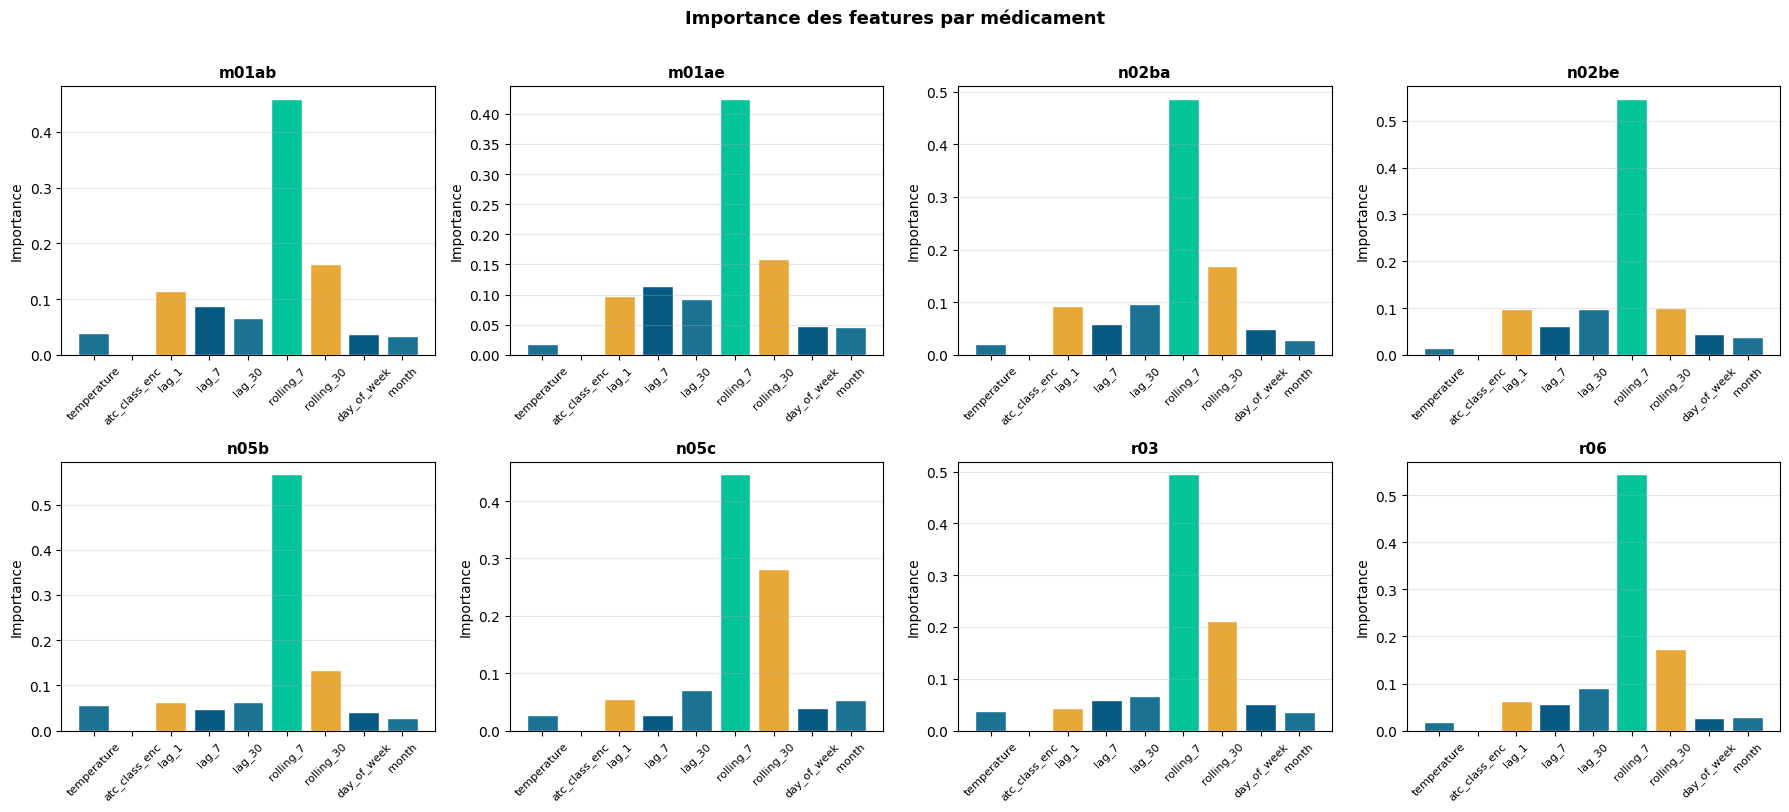

In [68]:
# Importance des features
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, product in enumerate(PRODUITS):
    importances = modeles[product].feature_importances_
    axes[i].bar(FEATURE_COLS, importances,
                color=['#1C7293','#02C39A','#E8A838','#065A82'],
                edgecolor='white')
    axes[i].set_title(f'{product}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Importance')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Importance des features par médicament', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gb_feature_importance.png', dpi=150)
plt.show()


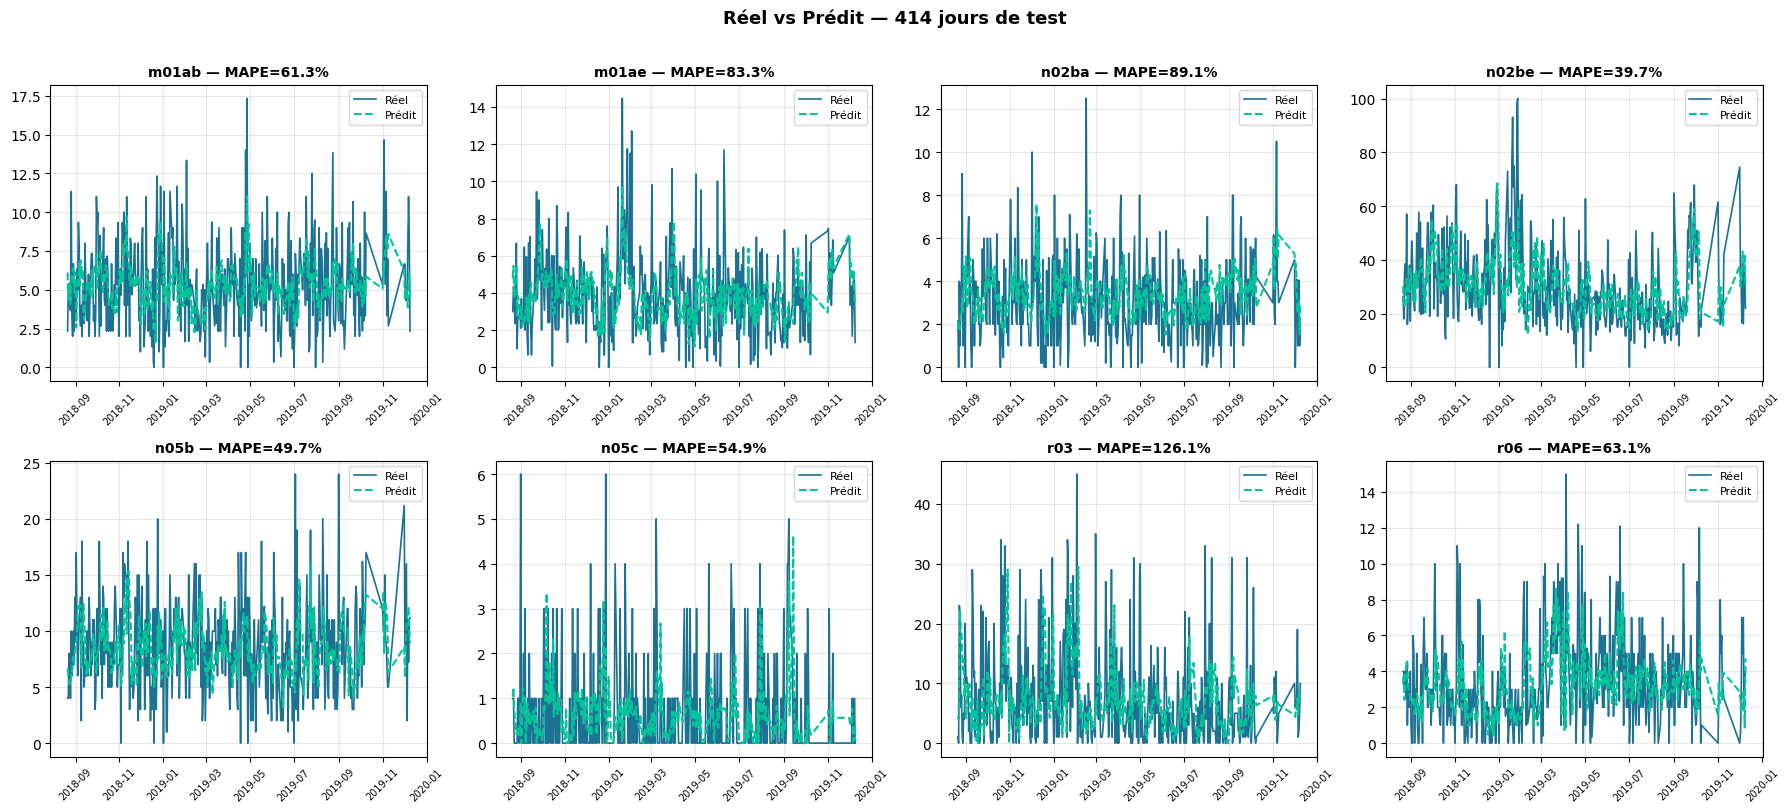

In [69]:
# Tous les produits — Réel vs Prédit
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, product in enumerate(PRODUITS):
    p = pred_test[product]
    axes[i].plot(p['dates'], p['y_reel'],
                 color='#1C7293', linewidth=1.2, label='Réel')
    axes[i].plot(p['dates'], p['y_pred'],
                 color='#02C39A', linewidth=1.5, linestyle='--', label='Prédit')
    axes[i].set_title(f"{product} — MAPE={resultats[product]['mape']}%",
                      fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Réel vs Prédit — 414 jours de test',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gb_tous_produits.png', dpi=150)
plt.show()


## Étape 7 — Prévisions des 30 prochains jours

In [70]:
# ============================================================
# GÉNÉRATION DES PRÉVISIONS FUTURES (30 jours)
# ============================================================

toutes_previsions = []

for product in PRODUITS:

    sub = df_feat[df_feat['product_id'] == product].copy()
    sub = sub.sort_values('date').reset_index(drop=True)

    # dernières informations connues
    derniere_date = sub['date'].max()
    atc_enc = int(sub['atc_class_enc'].iloc[0])

    lag_1 = sub['quantity_sold'].iloc[-1]
    lag_7 = sub['quantity_sold'].iloc[-7]
    lag_30 = sub['quantity_sold'].iloc[-30]

    rolling_7 = sub['quantity_sold'].tail(7).mean()
    rolling_30 = sub['quantity_sold'].tail(30).mean()

    historique = list(sub['quantity_sold'].tail(30))

    for i in range(1, 31):

        future_date = derniere_date + pd.Timedelta(days=i)



        temperature = TEMP_[future_date.month]

        day_of_week = future_date.dayofweek

        month = future_date.month

        row = [[
            temperature,
            atc_enc,
            lag_1,
            lag_7,
            lag_30,
            rolling_7,
            rolling_30,
            day_of_week,
            month
        ]]

        prediction = max(
            0,
            modeles[product].predict(row)[0]
        )

        toutes_previsions.append({
            "product_id": product,
            "date": future_date.strftime("%Y-%m-%d"),
            "prevision": round(prediction, 2),
            "temperature": temperature,
        })

        # Mise à jour des lags pour le jour suivant
        historique.append(prediction)

        lag_1 = historique[-1]
        lag_7 = historique[-7]
        lag_30 = historique[-30]

        rolling_7 = np.mean(historique[-7:])
        rolling_30 = np.mean(historique[-30:])

# Création du DataFrame final
df_prev = pd.DataFrame(toutes_previsions)

print("✔ Prévisions générées avec succès")
print(f"✔ {len(PRODUITS)} produits")
print(f"✔ {len(df_prev)} lignes générées")

display(df_prev.head(20))

✔ Prévisions générées avec succès
✔ 8 produits
✔ 240 lignes générées


,product_id,date,prevision,temperature
0,m01ab,2019-12-10,4.70,11
1,m01ab,2019-12-11,4.26,11
2,m01ab,2019-12-12,3.77,11
3,m01ab,2019-12-13,5.36,11
4,m01ab,2019-12-14,5.13,11
5,m01ab,2019-12-15,4.38,11
6,m01ab,2019-12-16,1.16,11
7,m01ab,2019-12-17,2.47,11
8,m01ab,2019-12-18,2.17,11
9,m01ab,2019-12-19,3.18,11


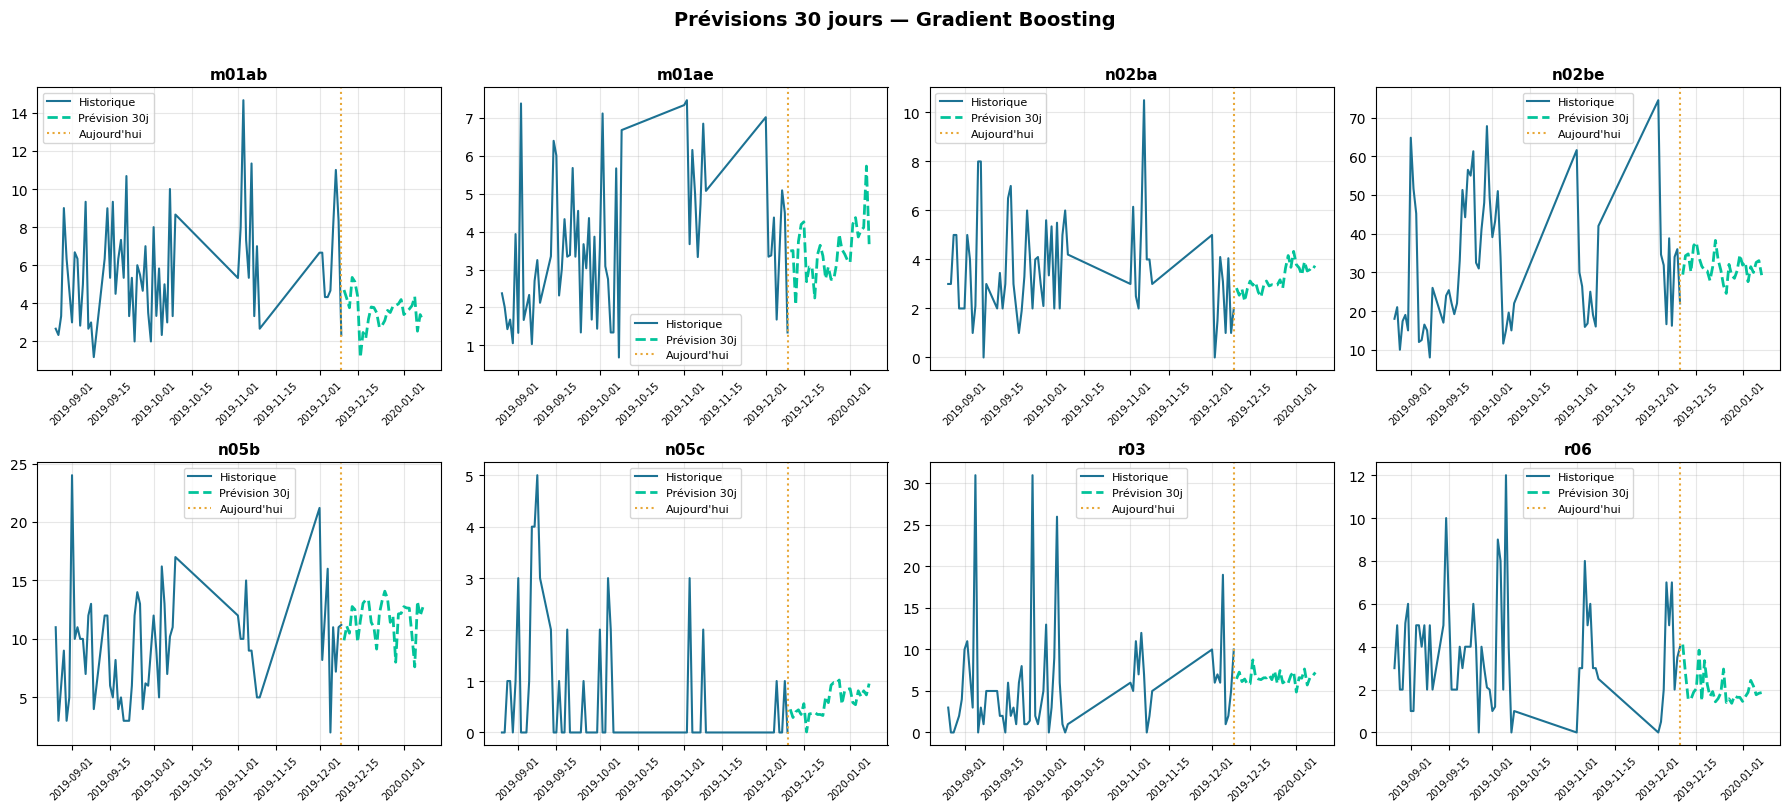

In [71]:
# Visualisation prévisions — tous les produits
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, product in enumerate(PRODUITS):
    sub  = df_feat[df_feat['product_id'] == product].copy()
    hist = sub.sort_values('date').tail(60)[['date', TARGET]]
    prev = df_prev[df_prev['product_id'] == product].copy()
    prev['date'] = pd.to_datetime(prev['date'])

    axes[i].plot(hist['date'], hist[TARGET],
                 color='#1C7293', linewidth=1.5, label='Historique')
    axes[i].plot(prev['date'], prev['prevision'],
                 color='#02C39A', linewidth=2, linestyle='--', label='Prévision 30j')
    axes[i].axvline(x=hist['date'].max(),
                color='#E8A838', linestyle=':', linewidth=1.5, label="Aujourd'hui")
    axes[i].set_title(product, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Prévisions 30 jours — Gradient Boosting',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gb_previsions_30jours.png', dpi=150)
plt.show()


## Étape 8 — Sauvegarde des résultats

In [72]:
# Sauvegarde
# 1. Métriques
df_res = pd.DataFrame(resultats).T.reset_index()
df_res.columns = ['product_id', 'mae', 'rmse', 'mape']
df_res.to_csv('gb_resultats.csv', index=False)
print("✔ gb_resultats.csv")

# 2. Prévisions 30 jours
df_prev.to_csv('gb_previsions_30jours.csv', index=False)
print("✔ gb_previsions_30jours.csv")

# 3. Prédictions test
rows = []
for product, p in pred_test.items():
    for d, reel, pred in zip(p['dates'], p['y_reel'], p['y_pred']):
        rows.append({
            'product_id': product,
            'date':       pd.Timestamp(d).strftime('%Y-%m-%d'),
            'reel':       round(float(reel), 2),
            'predit':     round(float(pred), 2),
            'erreur_abs': round(abs(float(reel) - float(pred)), 2),
        })
pd.DataFrame(rows).to_csv('gb_predictions_test.csv', index=False)
print("✔ gb_predictions_test.csv")
print(f"✔ {len(modeles)} modèles sauvegardés dans modeles/")

# Téléchargement automatique
from google.colab import files
for fname in ['gb_resultats.csv', 'gb_previsions_30jours.csv', 'gb_predictions_test.csv']:
    files.download(fname)

print("\n✔ Fichiers téléchargés sur votre ordinateur")


✔ gb_resultats.csv
✔ gb_previsions_30jours.csv
✔ gb_predictions_test.csv
✔ 8 modèles sauvegardés dans modeles/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✔ Fichiers téléchargés sur votre ordinateur


## Résumé final




### Fichiers générés :
- `gb_resultats.csv` → métriques MAE/RMSE/MAPE par produit
- `gb_previsions_30jours.csv` → prévisions futures
- `gb_predictions_test.csv` → réel vs prédit (60 jours)
- `modeles/modele_*.pkl` → 8 modèles sauvegardés


# Instalation FASTAPI

In [73]:
!pip install fastapi uvicorn pyngrok nest-asyncio --quiet
import nest_asyncio
# nest_asyncio.apply()
print("OK — FastAPI + ngrok installes")

OK — FastAPI + ngrok installes


In [74]:
import pickle, json, os

os.makedirs("modeles", exist_ok=True)

for product, modele in modeles.items():
    with open(f"modeles/modele_{product}.pkl", "wb") as f:
        pickle.dump(modele, f)

with open("resultats.json", "w") as f:
    json.dump(resultats, f)

print(f"OK — {len(modeles)} modeles sauvegardes")
print(f"Fichiers : {os.listdir('modeles')}")

OK — 8 modeles sauvegardes
Fichiers : ['modele_n05b.pkl', 'modele_m01ab.pkl', 'modele_n02be.pkl', 'modele_r03.pkl', 'modele_r06.pkl', 'modele_n05c.pkl', 'modele_n02ba.pkl', 'modele_m01ae.pkl']


In [75]:
app_code = '''
import pickle, json, os, numpy as np
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import Optional
from datetime import datetime, timedelta

PRODUITS = ["m01ab","m01ae","n02ba","n02be","n05b","n05c","r03","r06"]
modeles = {}
for p in PRODUITS:
    path = f"modeles/modele_{p}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            modeles[p] = pickle.load(f)

with open("resultats.json", "r") as f:
    resultats = json.load(f)

ATC_CLASSES = {
    "m01ab":"anti_inflammatoire","m01ae":"anti_inflammatoire",
    "n02ba":"analgesique","n02be":"analgesique",
    "n05b":"anxiolytique","n05c":"hypnotique",
    "r03":"respiratoire","r06":"antihistaminique",
}
ATC_ENC  = {"anti_inflammatoire":0,"analgesique":1,"anxiolytique":2,
            "antihistaminique":3,"hypnotique":4,"respiratoire":5}
TEMP_ = {1:11,2:13,3:16,4:19,5:23,6:28,7:33,8:32,9:27,10:21,11:15,12:11}
STOCK_SEC= {"m01ab":500,"m01ae":400,"n02ba":300,"n02be":2000,
            "n05b":600,"n05c":100,"r03":400,"r06":300}

historiques = {}

app = FastAPI(title="Medication Demand Prediction API", version="1.0.0")
app.add_middleware(CORSMiddleware, allow_origins=["*"],
                  allow_methods=["*"], allow_headers=["*"])

class PredictRequest(BaseModel):
    product_id: str
    nb_jours: Optional[int] = 30
    stock_actuel: Optional[float] = None

@app.get("/")
def root():
    return {"message":"Medication Demand Prediction API",
            "version":"1.0.0","produits":PRODUITS}

def build_row(product, future_date, hist):
    """
    Construit une ligne de features — ordre exact FEATURE_COLS du notebook :
    temperature, atc_class_enc, lag_1, lag_7, lag_30,
    rolling_7, rolling_30, day_of_week, month
    """
    atc_enc     = ATC_ENC[ATC_CLASSES[product]]
    temperature = TEMP_[future_date.month]
    day_of_week = future_date.weekday()
    month       = future_date.month

    lag_1  = hist[-1]  if len(hist) >= 1  else 0
    lag_7  = hist[-7]  if len(hist) >= 7  else (np.mean(hist) if hist else 0)
    lag_30 = hist[-30] if len(hist) >= 30 else (np.mean(hist) if hist else 0)

    rolling_7  = np.mean(hist[-7:])  if len(hist) >= 7  else (np.mean(hist) if hist else 0)
    rolling_30 = np.mean(hist[-30:]) if len(hist) >= 30 else (np.mean(hist) if hist else 0)

    return [[
        temperature,   # 1
        atc_enc,       # 2
        lag_1,         # 3
        lag_7,         # 4
        lag_30,        # 5
        rolling_7,     # 6
        rolling_30,    # 7
        day_of_week,   # 8
        month,         # 9
    ]]

@app.post("/predict")
def predict(req: PredictRequest):
    product = req.product_id.lower()
    if product not in modeles:
        return {"error": f"Produit inconnu : {product}. Disponibles : {PRODUITS}"}

    nb    = min(max(req.nb_jours, 1), 90)
    today = datetime.today()
    hist  = list(historiques.get(product, [0] * 30))
    previsions = []

    for i in range(1, nb + 1):
        fd   = today + timedelta(days=i)
        row  = build_row(product, fd, hist)
        pred = max(0, modeles[product].predict(row)[0])
        previsions.append({
            "date":        fd.strftime("%Y-%m-%d"),
            "jour":        fd.strftime("%A"),
            "prevision":   round(pred, 2),
            "temperature": TEMP_[fd.month],
        })
        hist.append(pred)

    total  = sum(p["prevision"] for p in previsions)
    moy    = round(total / nb, 2)
    result = {
        "product_id":       product,
        "atc_class":        ATC_CLASSES[product],
        "nb_jours":         nb,
        "total_prevu":      round(total, 2),
        "moyenne_par_jour": moy,
        "previsions":       previsions,
    }
    if req.stock_actuel is not None:
        jours = int(req.stock_actuel / moy) if moy > 0 else 999
        result["stock_actuel"]   = req.stock_actuel
        result["jours_restants"] = jours
        result["alerte"] = ("RUPTURE IMMINENTE" if jours < 7 else
                            "STOCK FAIBLE"      if jours < 15 else "STOCK OK")
    return result

@app.get("/recommend")
def recommend(product_id: str, stock_actuel: float):
    product = product_id.lower()
    if product not in modeles:
        return {"error": f"Produit inconnu : {product}"}

    today     = datetime.today()
    hist      = list(historiques.get(product, [0] * 30))
    total_30j = 0

    for i in range(1, 31):
        fd   = today + timedelta(days=i)
        row  = build_row(product, fd, hist)
        pred = max(0, modeles[product].predict(row)[0])
        total_30j += pred
        hist.append(pred)

    demande = round(total_30j, 2)
    moy     = round(demande / 30, 2)
    ssec    = STOCK_SEC[product]
    qte     = max(0, round(demande + ssec - stock_actuel, 2))
    jours   = int(stock_actuel / moy) if moy > 0 else 999

    if   jours < 7:  statut = "RUPTURE IMMINENTE"; prio = "HAUTE"
    elif jours < 15: statut = "STOCK FAIBLE";      prio = "MOYENNE"
    elif qte > 0:    statut = "REAPPROVISIONNEMENT CONSEILLE"; prio = "NORMALE"
    else:            statut = "STOCK SUFFISANT";   prio = "AUCUNE"

    return {
        "product_id":           product,
        "atc_class":            ATC_CLASSES[product],
        "stock_actuel":         stock_actuel,
        "stock_securite":       ssec,
        "demande_prevue_30j":   demande,
        "moyenne_par_jour":     moy,
        "jours_restants":       jours,
        "quantite_a_commander": qte,
        "statut":               statut,
        "priorite":             prio,
        "recommandation":       f"Commander {qte} unites de {product}" if qte > 0 else "Aucune commande necessaire",
    }

@app.get("/metrics")
def metrics(product_id: Optional[str] = None):
    if product_id:
        p = product_id.lower()
        if p not in resultats:
            return {"error": f"Produit inconnu : {p}"}
        r    = resultats[p]
        mape = r["mape"]
        qual = "Excellent" if mape<20 else "Bon" if mape<35 else "Moyen" if mape<50 else "Faible"
        return {"product_id":p,"atc_class":ATC_CLASSES[p],
                "mae":r["mae"],"rmse":r["rmse"],"mape":r["mape"],"qualite":qual}

    tous = []
    for p in sorted(resultats):
        r    = resultats[p]
        mape = r["mape"]
        qual = "Excellent" if mape<20 else "Bon" if mape<35 else "Moyen" if mape<50 else "Faible"
        tous.append({"product_id":p,"atc_class":ATC_CLASSES[p],
                     "mae":r["mae"],"rmse":r["rmse"],"mape":r["mape"],"qualite":qual})

    return {
        "modele":     "Gradient Boosting",
        "nb_modeles": len(resultats),
        "features":   ["temperature","atc_class_enc","lag_1","lag_7","lag_30",
                       "rolling_7","rolling_30","day_of_week","month","is_weekend"],
        "mape_moyen": round(np.mean([r["mape"] for r in resultats.values()]), 1),
        "mae_moyen":  round(np.mean([r["mae"]  for r in resultats.values()]), 2),
        "resultats":  tous,
    }

@app.on_event("startup")
def load_historiques():
    print(f"API demarree avec {len(modeles)} modeles charges")
    print(f"Features (10) : temperature, atc_class_enc, lag_1, lag_7, lag_30, rolling_7, rolling_30, day_of_week, month, is_weekend")
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("OK — app.py cree avec 9 features :")
print("  1. temperature")
print("  2. atc_class_enc")
print("  3. lag_1")
print("  4. lag_7")
print("  5. lag_30")
print("  6. rolling_7")
print("  7. rolling_30")
print("  8. day_of_week")
print("  9. month")

OK — app.py cree avec 9 features :
  1. temperature
  2. atc_class_enc
  3. lag_1
  4. lag_7
  5. lag_30
  6. rolling_7
  7. rolling_30
  8. day_of_week
  9. month


In [76]:
import uvicorn, threading, time, requests
from pyngrok import ngrok

# NE PAS utiliser nest_asyncio ici

NGROK_TOKEN = "3EZts5ctWSUqaaSUZPO2Gq0xHwB_p4EpWS49fUkS4r7isHdA"
ngrok.set_auth_token(NGROK_TOKEN)

# Lancer l'API SANS nest_asyncio
def run_api():
    import asyncio
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    uvicorn.run("app:app", host="0.0.0.0", port=8000, log_level="warning")

thread = threading.Thread(target=run_api, daemon=True)
thread.start()

print("Demarrage de l'API...")
time.sleep(8)

for i in range(10):
    try:
        r = requests.get("http://localhost:8000/", timeout=2)
        if r.status_code == 200:
            print("API OK !")
            break
    except:
        print(f"Attente {i+1}/10...")
        time.sleep(3)

public_url = ngrok.connect(8000)
public_url_str = public_url.public_url

print("=" * 55)
print("API PUBLIQUE ACCESSIBLE !")
print("=" * 55)
print(f"URL ngrok : {public_url_str}")
print(f"Docs      : {public_url_str}/docs")
print("=" * 55)
print(f"\nCopiez cette URL dans dashboard.html :")
print(f"  --> {public_url_str}")

Demarrage de l'API...


ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


API demarree avec 8 modeles charges
Features (10) : temperature, atc_class_enc, lag_1, lag_7, lag_30, rolling_7, rolling_30, day_of_week, month, is_weekend
API OK !
API PUBLIQUE ACCESSIBLE !
URL ngrok : https://naturist-barge-freewill.ngrok-free.dev
Docs      : https://naturist-barge-freewill.ngrok-free.dev/docs

Copiez cette URL dans dashboard.html :
  --> https://naturist-barge-freewill.ngrok-free.dev


In [77]:
import requests

base = "http://localhost:8000"

print("TEST 1 — GET /")
r = requests.get(f"{base}/")
print(f"  OK : {r.json()['message']}")

print("\nTEST 2 — POST /predict")
r = requests.post(f"{base}/predict",
    json={"product_id":"n02be","nb_jours":30,"stock_actuel":500})
res = r.json()
print(f"  Total prevu    : {res['total_prevu']}")
print(f"  Jours restants : {res.get('jours_restants')}")
print(f"  Alerte         : {res.get('alerte')}")

print("\nTEST 3 — GET /recommend")
r = requests.get(f"{base}/recommend",
    params={"product_id":"m01ab","stock_actuel":200})
res = r.json()
print(f"  Statut      : {res['statut']}")
print(f"  A commander : {res['quantite_a_commander']}")

print("\nTEST 4 — GET /metrics")
r = requests.get(f"{base}/metrics")
res = r.json()
print(f"  MAPE moyen : {res['mape_moyen']}%")

print("\n" + "="*45)
print("TOUS LES TESTS PASSES !")
print("="*45)

TEST 1 — GET /
  OK : Medication Demand Prediction API

TEST 2 — POST /predict
  Total prevu    : 1231.69
  Jours restants : 12
  Alerte         : STOCK FAIBLE

TEST 3 — GET /recommend
  Statut      : REAPPROVISIONNEMENT CONSEILLE
  A commander : 394.69

TEST 4 — GET /metrics
  MAPE moyen : 70.9%

TOUS LES TESTS PASSES !


In [78]:
from IPython.display import display, HTML, FileLink
import requests

# Récupérer l'URL ngrok active
from pyngrok import ngrok
tunnels = ngrok.get_tunnels()
if tunnels:
    api_url = tunnels[0].public_url
    print(f"URL ngrok : {api_url}")
else:
    api_url = "https://naturist-barge-freewill.ngrok-free.dev"
    print(f"URL utilisee : {api_url}")

# Créer le fichier dashboard.html
dashboard = f"""<!DOCTYPE html>
<html lang="fr">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Medication Demand Dashboard</title>
<style>
  * {{ box-sizing:border-box; margin:0; padding:0; }}
  body {{ font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif; background:#f5f5f5; }}
  .container {{ max-width:1100px; margin:0 auto; padding:24px; }}
  .header {{ background:#1C7293; color:white; padding:20px 24px; border-radius:12px; margin-bottom:20px; display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:12px; }}
  .header h1 {{ font-size:20px; font-weight:600; margin:0; }}
  .header p {{ font-size:12px; opacity:0.8; margin:4px 0 0; }}
  .url-badge {{ background:rgba(255,255,255,0.2); padding:6px 12px; border-radius:8px; font-size:11px; font-family:monospace; word-break:break-all; max-width:400px; }}
  .metrics {{ display:grid; grid-template-columns:repeat(4,1fr); gap:12px; margin-bottom:20px; }}
  .metric {{ background:white; border-radius:10px; padding:16px; border:1px solid #e5e7eb; }}
  .metric-label {{ font-size:12px; color:#6b7280; margin-bottom:6px; }}
  .metric-val {{ font-size:28px; font-weight:600; }}
  .card {{ background:white; border-radius:12px; border:1px solid #e5e7eb; padding:20px; margin-bottom:16px; }}
  .card-title {{ font-size:15px; font-weight:600; margin-bottom:4px; }}
  .card-sub {{ font-size:12px; color:#6b7280; margin-bottom:16px; }}
  .stocks-grid {{ display:grid; grid-template-columns:repeat(4,1fr); gap:12px; }}
  .field label {{ font-size:11px; color:#6b7280; display:block; margin-bottom:4px; }}
  .field input {{ width:100%; padding:8px 10px; border:1px solid #d1d5db; border-radius:8px; font-size:13px; outline:none; }}
  .field input:focus {{ border-color:#1C7293; }}
  .btn {{ background:#1C7293; color:white; border:none; border-radius:8px; padding:10px 24px; font-size:13px; font-weight:500; cursor:pointer; margin-top:14px; }}
  .btn:hover {{ background:#155e75; }}
  .btn:disabled {{ background:#93c5fd; cursor:not-allowed; }}
  table {{ width:100%; border-collapse:collapse; font-size:13px; }}
  th {{ font-size:12px; font-weight:500; color:#6b7280; text-align:left; padding:8px 12px; border-bottom:1px solid #e5e7eb; }}
  td {{ padding:11px 12px; border-bottom:1px solid #f3f4f6; }}
  tr:last-child td {{ border-bottom:none; }}
  tr:hover td {{ background:#f9fafb; }}
  .badge {{ font-size:11px; font-weight:500; padding:3px 10px; border-radius:20px; display:inline-block; }}
  .high {{ background:#fee2e2; color:#dc2626; }}
  .medium {{ background:#fef3c7; color:#d97706; }}
  .low {{ background:#dcfce7; color:#16a34a; }}
  .info {{ background:#dbeafe; color:#2563eb; }}
  .empty {{ text-align:center; color:#9ca3af; padding:32px; }}
  .spinner {{ display:inline-block; width:12px; height:12px; border:2px solid #bfdbfe; border-top-color:#1C7293; border-radius:50%; animation:spin 0.7s linear infinite; vertical-align:-2px; margin-right:5px; }}
  @keyframes spin {{ to {{ transform:rotate(360deg); }} }}
  @media(max-width:768px) {{ .metrics {{ grid-template-columns:repeat(2,1fr); }} .stocks-grid {{ grid-template-columns:repeat(2,1fr); }} }}
</style>
</head>
<body>
<div class="container">

  <div class="header">
    <div>
      <h1>Medication Demand Prediction Dashboard</h1>
      <p>Gradient Boosting — 4 features | Prevision et recommandations de reapprovisionnement</p>
    </div>
    <div class="url-badge">{api_url}</div>
  </div>

  <div class="metrics">
    <div class="metric"><div class="metric-label">Produits analyses</div><div class="metric-val" id="m1" style="color:#1C7293">—</div></div>
    <div class="metric"><div class="metric-label">Besoin reapprovisionnement</div><div class="metric-val" id="m2" style="color:#d97706">—</div></div>
    <div class="metric"><div class="metric-label">Risque rupture</div><div class="metric-val" id="m3" style="color:#dc2626">—</div></div>
    <div class="metric"><div class="metric-label">Stock suffisant</div><div class="metric-val" id="m4" style="color:#16a34a">—</div></div>
  </div>

  <div class="card">
    <div class="card-title">Stocks actuels</div>
    <div class="card-sub">Saisissez le stock actuel de chaque medicament puis cliquez Lancer</div>
    <div class="stocks-grid">
      <div class="field"><label>m01ab — anti-inflammatoire</label><input type="number" id="s-m01ab" value="300" min="0"/></div>
      <div class="field"><label>m01ae — anti-inflammatoire</label><input type="number" id="s-m01ae" value="250" min="0"/></div>
      <div class="field"><label>n02ba — analgesique (Aspirine)</label><input type="number" id="s-n02ba" value="180" min="0"/></div>
      <div class="field"><label>n02be — analgesique (Paracetamol)</label><input type="number" id="s-n02be" value="800" min="0"/></div>
      <div class="field"><label>n05b — anxiolytique</label><input type="number" id="s-n05b" value="400" min="0"/></div>
      <div class="field"><label>n05c — hypnotique</label><input type="number" id="s-n05c" value="50" min="0"/></div>
      <div class="field"><label>r03 — respiratoire</label><input type="number" id="s-r03" value="120" min="0"/></div>
      <div class="field"><label>r06 — antihistaminique</label><input type="number" id="s-r06" value="200" min="0"/></div>
    </div>
    <button class="btn" id="btn" onclick="run()">&#9654; Lancer la prediction</button>
    <span id="status" style="font-size:12px;color:#6b7280;margin-left:12px"></span>
  </div>

  <div class="card">
    <div class="card-title">Prediction Results — 30 jours</div>
    <div class="card-sub" id="sub">Cliquez sur Lancer pour obtenir les previsions</div>
    <table>
      <thead><tr>
        <th>Medicament</th><th>Classe ATC</th>
        <th>Stock actuel</th><th>Demande 30j</th>
        <th>Jours restants</th><th>A commander</th>
        <th>Recommandation</th><th>Risque</th>
      </tr></thead>
      <tbody id="tbody"><tr><td colspan="8" class="empty">Aucune donnee — lancez une prediction</td></tr></tbody>
    </table>
  </div>

  <div class="card" id="mcard" style="display:none">
    <div class="card-title">Model Metrics — MAE / RMSE / MAPE</div>
    <div class="card-sub">Performance du modele Gradient Boosting par medicament</div>
    <table>
      <thead><tr>
        <th>Produit</th><th>Classe ATC</th>
        <th>MAE</th><th>RMSE</th><th>MAPE</th><th>Qualite</th>
      </tr></thead>
      <tbody id="mtbody"></tbody>
    </table>
  </div>

</div>
<script>
const API   = "{api_url}";
const PRODS = ["m01ab","m01ae","n02ba","n02be","n05b","n05c","r03","r06"];

async function apiFetch(url, opts={{}}) {{
  const res = await fetch(url, {{
    ...opts,
    headers: {{'Content-Type':'application/json','ngrok-skip-browser-warning':'true',...(opts.headers||{{}})}}
  }});
  if (!res.ok) throw new Error("HTTP "+res.status);
  return res.json();
}}

function riskBadge(s) {{
  if (!s) return '<span class="badge info">—</span>';
  const u=s.toUpperCase();
  if (u.includes("RUPTURE"))  return '<span class="badge high">High</span>';
  if (u.includes("FAIBLE")||u.includes("REAPPRO")) return '<span class="badge medium">Medium</span>';
  if (u.includes("SUFFISANT")) return '<span class="badge low">Low</span>';
  return '<span class="badge info">—</span>';
}}

function recLabel(s) {{
  if (!s) return "—";
  const u=s.toUpperCase();
  if (u.includes("RUPTURE"))  return '<span style="color:#dc2626;font-weight:500">Urgent restock</span>';
  if (u.includes("FAIBLE")||u.includes("REAPPRO")) return '<span style="color:#d97706;font-weight:500">Restock</span>';
  if (u.includes("SUFFISANT")) return '<span style="color:#16a34a">No action</span>';
  return s;
}}

function qualBadge(q) {{
  const m={{"Excellent":"low","Bon":"info","Moyen":"medium","Faible":"high"}};
  return '<span class="badge '+(m[q]||"info")+'">'+q+'</span>';
}}

async function run() {{
  document.getElementById("btn").disabled=true;
  document.getElementById("status").innerHTML='<span class="spinner"></span>Chargement...';
  document.getElementById("sub").textContent="Interrogation de l API...";

  let nH=0,nR=0,nO=0;
  const rows=[];

  for (const p of PRODS) {{
    const stock=parseFloat(document.getElementById("s-"+p).value)||0;
    try {{
      const [pred,rec]=await Promise.all([
        apiFetch(API+"/predict",{{method:"POST",body:JSON.stringify({{product_id:p,nb_jours:30,stock_actuel:stock}})}}),
        apiFetch(API+"/recommend?product_id="+p+"&stock_actuel="+stock)
      ]);
      rows.push({{p,stock,pred,rec}});
      const u=(rec.statut||"").toUpperCase();
      if (u.includes("RUPTURE")) nH++;
      else if (u.includes("FAIBLE")||u.includes("REAPPRO")) nR++;
      else nO++;
    }} catch(e) {{
      rows.push({{p,stock,error:e.message}});
    }}
  }}

  document.getElementById("m1").textContent=PRODS.length;
  document.getElementById("m2").textContent=nR;
  document.getElementById("m3").textContent=nH;
  document.getElementById("m4").textContent=nO;
  document.getElementById("sub").textContent="Resultats 30 jours — "+rows.length+" produits traites";
  document.getElementById("status").textContent="Mis a jour ✔";

  document.getElementById("tbody").innerHTML=rows.map(d=>{{
    if (d.error) return `<tr><td style="color:#dc2626;font-weight:500">${{d.p}}</td><td colspan="7" style="color:#dc2626;font-size:12px">${{d.error}}</td></tr>`;
    const r=d.rec;
    const dc=r.jours_restants<7?"#dc2626":r.jours_restants<15?"#d97706":"#16a34a";
    const qc=r.quantite_a_commander>0?"#d97706":"#16a34a";
    return `<tr>
      <td style="font-weight:500">${{d.p}}</td>
      <td style="color:#6b7280;font-size:12px">${{r.atc_class||"—"}}</td>
      <td>${{Math.round(d.stock)}}</td>
      <td style="font-weight:500">${{r.demande_prevue_30j||"—"}}</td>
      <td style="font-weight:500;color:${{dc}}">${{r.jours_restants||"—"}}j</td>
      <td style="font-weight:500;color:${{qc}}">${{r.quantite_a_commander||0}}</td>
      <td>${{recLabel(r.statut)}}</td>
      <td>${{riskBadge(r.statut)}}</td>
    </tr>`;
  }}).join("");

  try {{
    const m=await apiFetch(API+"/metrics");
    document.getElementById("mcard").style.display="block";
    document.getElementById("mtbody").innerHTML=(m.resultats||[]).map(r=>
      `<tr>
        <td style="font-weight:500">${{r.product_id}}</td>
        <td style="color:#6b7280;font-size:12px">${{r.atc_class}}</td>
        <td>${{r.mae}}</td><td>${{r.rmse}}</td>
        <td style="font-weight:500">${{r.mape}}%</td>
        <td>${{qualBadge(r.qualite)}}</td>
      </tr>`
    ).join("");
  }} catch(e) {{}}

  document.getElementById("btn").disabled=false;
}}
</script>
</body>
</html>"""

# Sauvegarder le fichier
with open("/content/dashboard.html", "w", encoding="utf-8") as f:
    f.write(dashboard)

print("="*50)
print("DASHBOARD CREE AVEC SUCCES !")
print("="*50)
print(f"API URL : {api_url}")
print()
print("Pour ouvrir le dashboard :")
print("1. Telechargez le fichier ci-dessous")
print("2. Double-cliquez pour ouvrir dans Chrome")
print("3. Cliquez Lancer la prediction")

# Lien de téléchargement
display(FileLink('/content/dashboard.html', result_html_prefix="Cliquez ici pour telecharger : "))

# Téléchargement automatique
from google.colab import files
files.download('/content/dashboard.html')

URL ngrok : https://naturist-barge-freewill.ngrok-free.dev
DASHBOARD CREE AVEC SUCCES !
API URL : https://naturist-barge-freewill.ngrok-free.dev

Pour ouvrir le dashboard :
1. Telechargez le fichier ci-dessous
2. Double-cliquez pour ouvrir dans Chrome
3. Cliquez Lancer la prediction


/content/dashboard.html

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
import requests
try:
    r = requests.get("http://localhost:8000/", timeout=3)
    print("API OK :", r.json())
except:
    print("API non accessible — relancez la cellule D")

API OK : {'message': 'Medication Demand Prediction API', 'version': '1.0.0', 'produits': ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06']}
